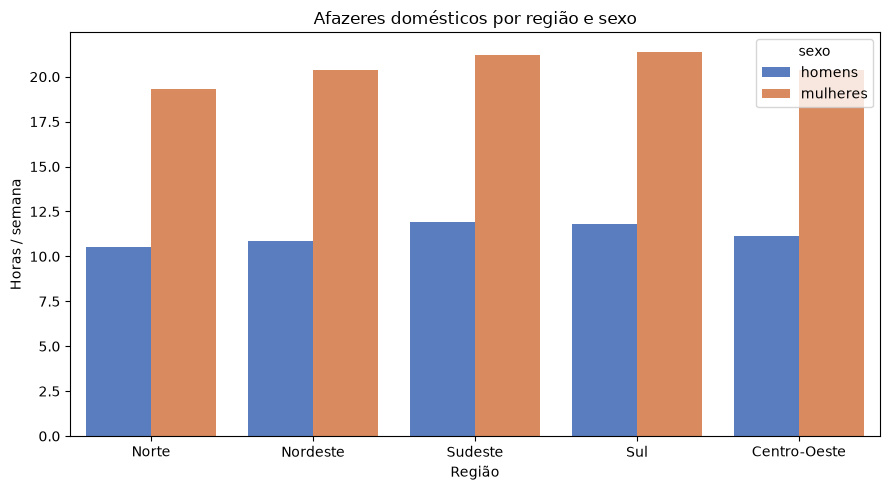

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#atividade 2

indicador_1 = pd.DataFrame(
    {
        "uf_regiao": ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"],
        "homem_branca": [10.2, 10.5, 11.8, 12.1, 11.0],
        "homem_preta_parda": [10.8, 11.2, 12.0, 11.5, 11.3],
        "mulher_branca": [18.5, 19.2, 20.1, 21.0, 19.8],
        "mulher_preta_parda": [20.1, 21.5, 22.3, 21.8, 21.0],
    }
)
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax, palette="muted"
)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

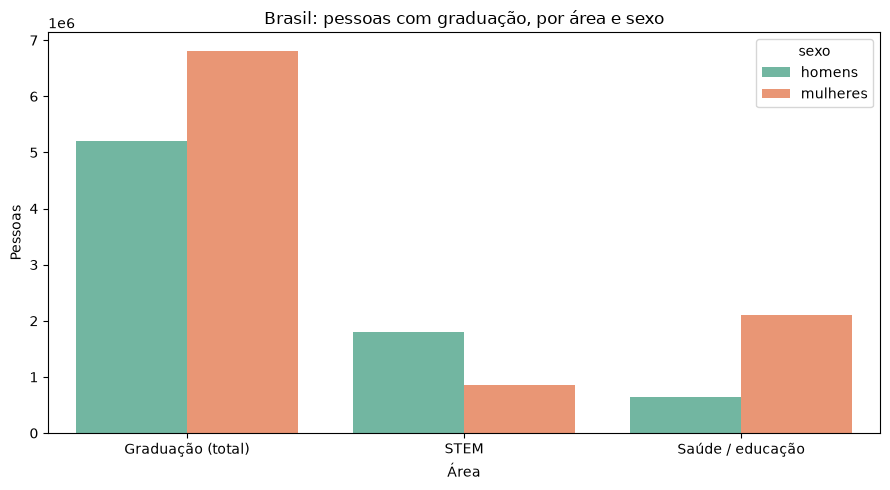

In [7]:
#atividade 3

formacao_total = pd.DataFrame(
    {"uf_regiao": ["Brasil"], "total_homens": [5200000], "total_mulheres": [6800000]}
)
formacao_stem = pd.DataFrame(
    {"uf_regiao": ["Brasil"], "homens": [1800000], "mulheres": [850000]}
)
formacao_saude = pd.DataFrame(
    {"uf_regiao": ["Brasil"], "homens": [650000], "mulheres": [2100000]}
)

brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[
                formacao_total["uf_regiao"] == "Brasil", "total_homens"
            ].item(),
            formacao_stem.loc[
                formacao_stem["uf_regiao"] == "Brasil", "homens"
            ].item(),
            formacao_saude.loc[
                formacao_saude["uf_regiao"] == "Brasil", "homens"
            ].item(),
        ],
        "mulheres": [
            formacao_total.loc[
                formacao_total["uf_regiao"] == "Brasil", "total_mulheres"
            ].item(),
            formacao_stem.loc[
                formacao_stem["uf_regiao"] == "Brasil", "mulheres"
            ].item(),
            formacao_saude.loc[
                formacao_saude["uf_regiao"] == "Brasil", "mulheres"
            ].item(),
        ],
    }
)

brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax, palette="Set2"
)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()

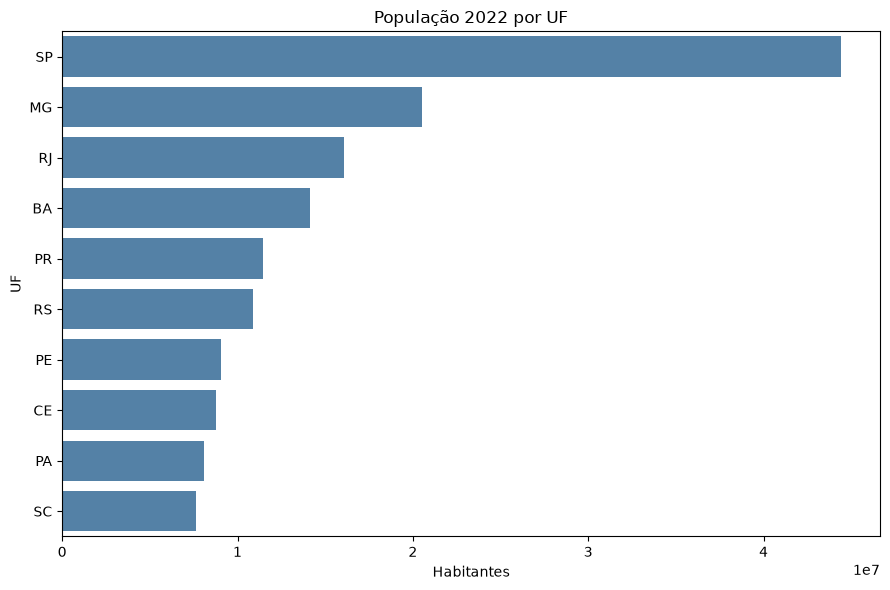

In [8]:
#atividade 4

pop_estado = pd.DataFrame(
    {
        "UF": ["SP", "MG", "RJ", "BA", "PR", "RS", "PE", "CE", "PA", "SC"],
        "2022": [
            44420459,
            20538718,
            16054524,
            14136417,
            11443208,
            10880506,
            9058155,
            8791688,
            8116132,
            7609601,
        ],
    }
)

fig, ax = plt.subplots(figsize=(9, 6))
ordem = pop_estado.sort_values("2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()

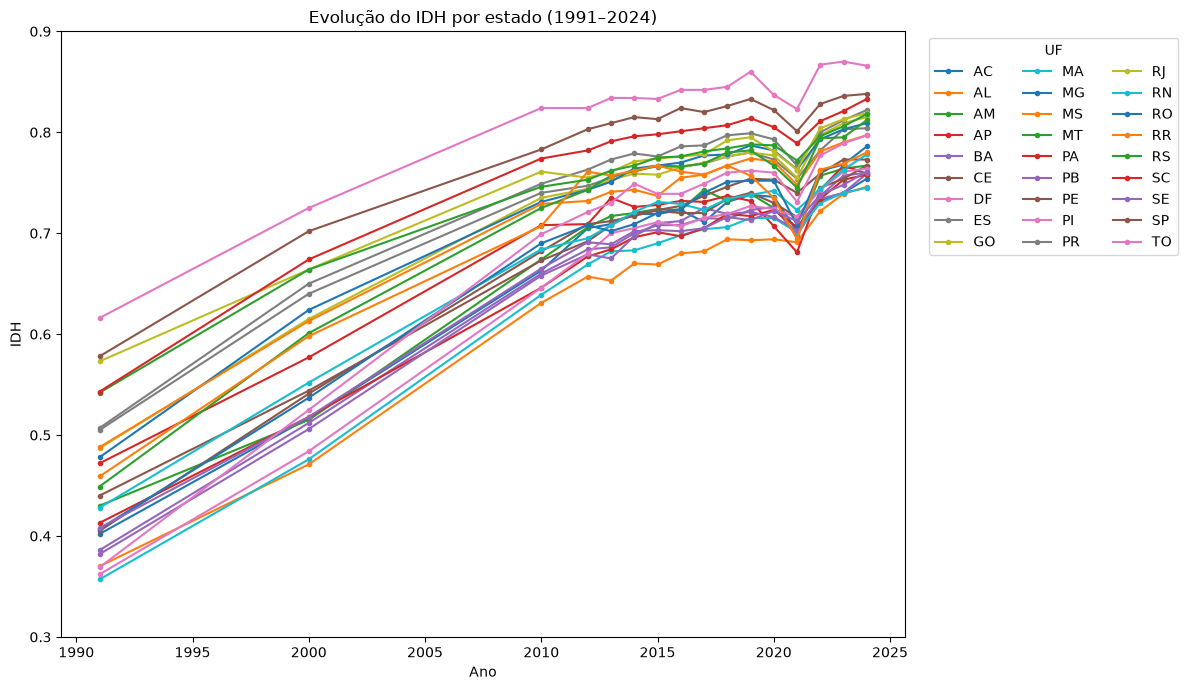

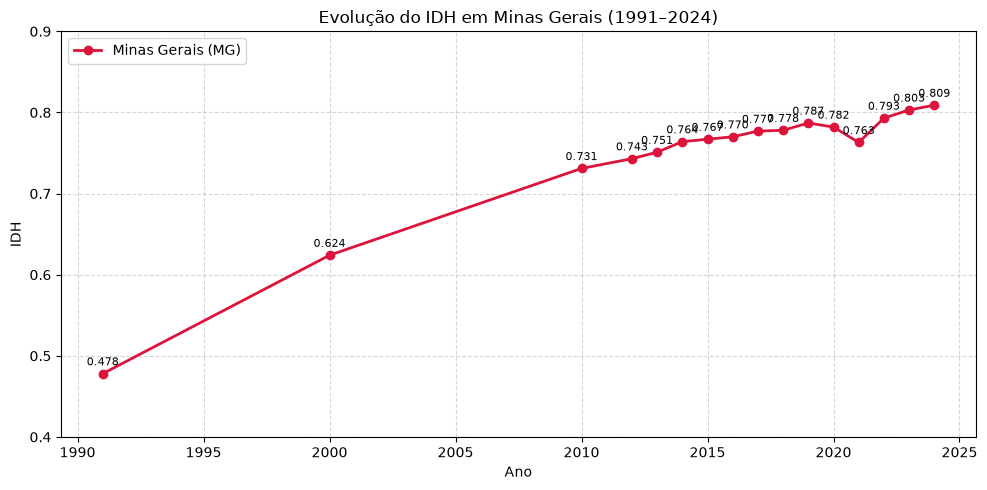

In [9]:
#parte 2

# 1 e 2. Abertura do CSV e limpeza de colunas nulas
df_idh = pd.read_csv(
    "Tabela4.csv", skiprows=1, sep=";", decimal=",", encoding="latin1"
)
df_idh = df_idh.dropna(how="all", axis=1)

# 3. Transformação do formato largo para longo (melt)
anos = [c for c in df_idh.columns if str(c).isdigit()]
variaveis = [c for c in df_idh.columns if c not in anos]

df_longo = df_idh.melt(
    id_vars=variaveis,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)

df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

# 4. Gráfico: Evolução do IDH de cada estado
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=sigla,
    )

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
plt.tight_layout()
plt.show()

# 5. Gráfico: IDH de Minas Gerais (MG)
mg_data = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    mg_data["Ano"],
    mg_data["IDH"],
    marker="o",
    color="crimson",
    linewidth=2,
    label="Minas Gerais (MG)",
)

for _, row in mg_data.iterrows():
    ax.annotate(
        f"{row['IDH']:.3f}",
        (row["Ano"], row["IDH"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
    )

ax.set_title("Evolução do IDH em Minas Gerais (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.4, 0.9)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()